In [1]:
!pip install --upgrade pip
!pip -q install pymorphy3 pymorphy3-dicts-ru

  Using cached pip-25.3-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-25.3-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 24.3.1
    Uninstalling pip-24.3.1:
      Successfully uninstalled pip-24.3.1


In [2]:
import bz2
import json
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import pymorphy3
import regex

from collections import Counter
from functools import lru_cache
from gensim.corpora import Dictionary
from gensim.models import LdaModel
from nltk.corpus import stopwords
from sklearn.decomposition import LatentDirichletAllocation, TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from tqdm import tqdm

%matplotlib inline
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [3]:
responses = []
with bz2.BZ2File('banki_responses.json.bz2', 'r') as thefile:
    for row in tqdm(thefile):
        resp = json.loads(row)
        if not resp['rating_not_checked'] and (len(resp['text'].split()) > 0):
            responses.append(resp)

201030it [00:25, 7939.67it/s] 



Посмотрим на пример отзыва:

In [4]:
responses[99]

{'city': 'г. Саратов',
 'rating_not_checked': False,
 'title': 'Карта ко вкладу',
 'num_comments': 0,
 'bank_license': 'лицензия № 880',
 'author': 'ronnichka',
 'bank_name': 'Югра',
 'datetime': '2015-06-03 20:56:57',
 'text': 'Здравствуйте! Хотела написать, что мне месяц не выдают карту ко вкладу, ссылаясь на "нам же их из Самары везут" (на секундочку 5 часов езды от нашего города). Но! Прочитала, что людям 3,5 месяцев не выдают карту, и поняла, что у меня все хорошо, пока что. И подарок мне дали, и кулер в отделении есть. Так что я, конечно, готова ждать. Правда хотелось бы не очень долго.',
 'rating_grade': 3}

## Часть 1. Анализ текстов

1. Посчитайте количество отзывов в разных городах и на разные банки

In [5]:
df = pd.DataFrame(responses)

# города
city_counts = Counter(df['city'])
city_counts.most_common(10)

# банки
bank_counts = Counter(df['bank_name'])
bank_counts.most_common(10)

[('Сбербанк России', 26327),
 ('Альфа-Банк', 10224),
 ('ВТБ 24', 8185),
 ('Русский Стандарт', 7943),
 ('Хоум Кредит Банк', 7549),
 ('Тинькофф Банк', 5387),
 ('Национальный Банк «Траст»', 4607),
 ('Ренессанс Кредит', 3849),
 ('Связной Банк', 3775),
 ('ОТП Банк', 3237)]

In [6]:
bank_counts = df['bank_name'].value_counts()
bank_counts.head(10)

bank_name
Сбербанк России              26327
Альфа-Банк                   10224
ВТБ 24                        8185
Русский Стандарт              7943
Хоум Кредит Банк              7549
Тинькофф Банк                 5387
Национальный Банк «Траст»     4607
Ренессанс Кредит              3849
Связной Банк                  3775
ОТП Банк                      3237
Name: count, dtype: int64

2. Постройте гистограммы длин отзывов в символах и в словах

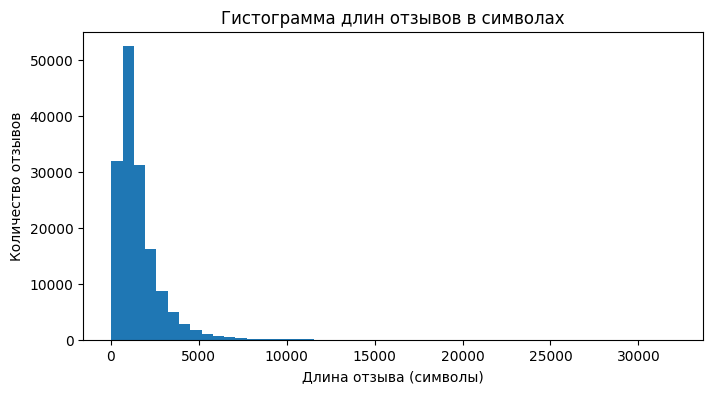

In [7]:
df['len_chars'] = df['text'].apply(len)

plt.figure(figsize=(8, 4))
plt.hist(df['len_chars'], bins=50)
plt.xlabel('Длина отзыва (символы)')
plt.ylabel('Количество отзывов')
plt.title('Гистограмма длин отзывов в символах')
plt.show()

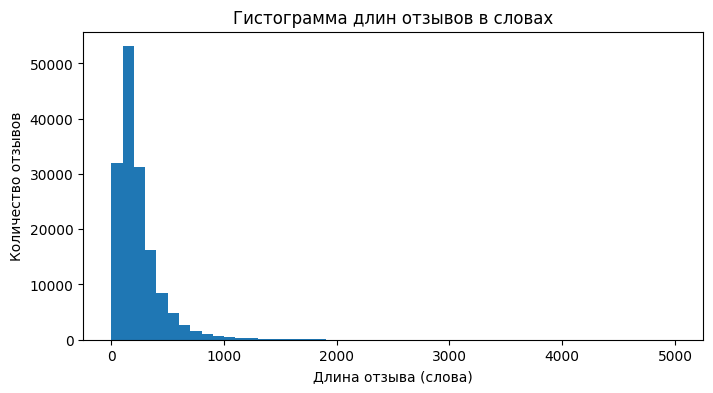

In [8]:
df['len_words'] = df['text'].apply(lambda x: len(x.split()))
plt.figure(figsize=(8, 4))
plt.hist(df['len_words'], bins=50)
plt.xlabel('Длина отзыва (слова)')
plt.ylabel('Количество отзывов')
plt.title('Гистограмма длин отзывов в словах')
plt.show()

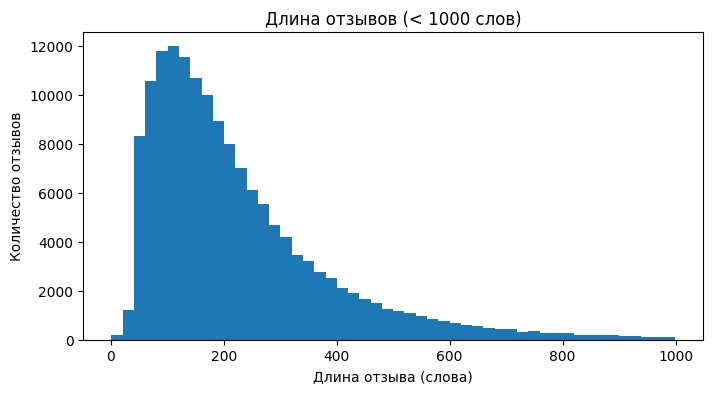

In [9]:
plt.figure(figsize=(8, 4))
plt.hist(df[df['len_words'] < 1000]['len_words'], bins=50)
plt.xlabel('Длина отзыва (слова)')
plt.ylabel('Количество отзывов')
plt.title('Длина отзывов (< 1000 слов)')
plt.show()

3. Найдите 10 самых частых:

    1. слов
    2. слов без стоп-слов
    3. лемм
    4. существительных


In [10]:
nltk.download('stopwords')

ru_stop = set(stopwords.words('russian'))


def tokenize(text):
    return regex.findall(r'\p{L}+', text.lower())


df['tokens'] = df['text'].apply(tokenize)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/andreivasilev/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [11]:
word_counts = Counter(t for toks in df['tokens'] for t in toks)
word_counts.most_common(10)

[('в', 1330291),
 ('и', 1058982),
 ('не', 852428),
 ('на', 707799),
 ('что', 640057),
 ('я', 577484),
 ('с', 462744),
 ('по', 372755),
 ('мне', 320958),
 ('банка', 275899)]

In [12]:
word_nostop_counts = Counter(
    t for toks in df['tokens'] for t in toks
    if t not in ru_stop
)
word_nostop_counts.most_common(10)

[('банка', 275899),
 ('банк', 215410),
 ('это', 183365),
 ('деньги', 131200),
 ('карту', 105827),
 ('карты', 101821),
 ('кредит', 81118),
 ('день', 76552),
 ('т', 75720),
 ('банке', 72162)]

In [13]:
morph = pymorphy3.MorphAnalyzer()

@lru_cache(maxsize=200000)
def parse_first(token: str):
    return morph.parse(token)[0]

lemma_counts = Counter()
noun_counts = Counter()

for tokens in df['tokens']:
    for token in tokens:
        p = parse_first(token)
        lemma = p.normal_form
        lemma_counts[lemma] += 1
        if 'NOUN' in p.tag:
            noun_counts[lemma] += 1

In [14]:
lemma_counts.most_common(10)

[('в', 1355121),
 ('я', 1122794),
 ('и', 1058982),
 ('не', 852428),
 ('на', 707799),
 ('банк', 668506),
 ('что', 664777),
 ('с', 523241),
 ('быть', 441344),
 ('по', 372755)]

In [15]:
noun_counts.most_common(10)

[('банк', 668506),
 ('карта', 334994),
 ('деньга', 179818),
 ('день', 173688),
 ('кредит', 156152),
 ('отделение', 144049),
 ('счёт', 142644),
 ('клиент', 136889),
 ('сотрудник', 134168),
 ('сумма', 111232)]

4. Постройте кривые Ципфа и Хипса

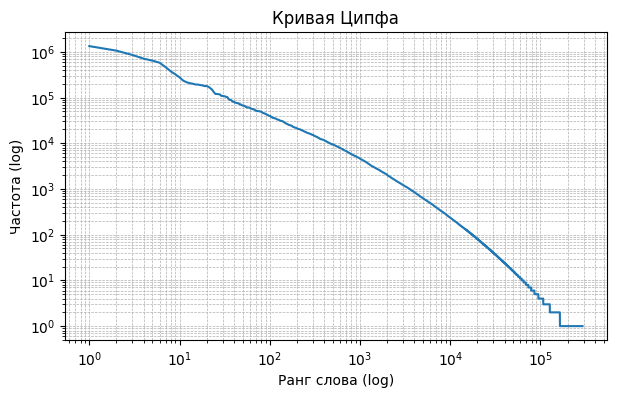

In [16]:
token_counts = Counter(token for tokens in df['tokens'] for token in tokens)
freqs = np.array(sorted(token_counts.values(), reverse=True))
ranks = np.arange(1, len(freqs) + 1)

plt.figure(figsize=(7, 4))
plt.plot(ranks, freqs)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Ранг слова (log)')
plt.ylabel('Частота (log)')
plt.title('Кривая Ципфа')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

  2%|▏         | 2508/153499 [00:00<00:02, 57379.75it/s]


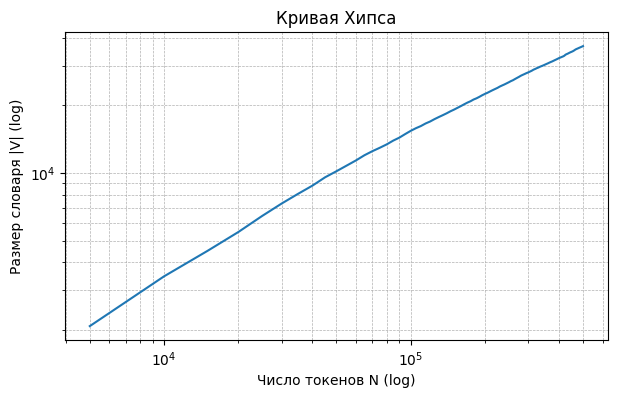

In [17]:
def heaps_curve(tokens_series, step=5000, max_tokens=None):
    vocab = set()
    n_seen = 0
    Ns = []
    Vs = []

    for tokens in tqdm(tokens_series, total=len(tokens_series)):
        for t in tokens:
            vocab.add(t)
            n_seen += 1
            if n_seen % step == 0:
                Ns.append(n_seen)
                Vs.append(len(vocab))
            if max_tokens is not None and n_seen >= max_tokens:
                return np.array(Ns), np.array(Vs)
    return np.array(Ns), np.array(Vs)

Ns, Vs = heaps_curve(df['tokens'], step=5000, max_tokens=500000)

plt.figure(figsize=(7, 4))
plt.plot(Ns, Vs)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Число токенов N (log)')
plt.ylabel('Размер словаря |V| (log)')
plt.title('Кривая Хипса')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.show()

5. Ответьте на следующие вопросы:

    1. какое слово встречается чаще, “сотрудник” или “клиент”?
    2. сколько раз встречается слова “мошенничество” и “доверие”?

In [18]:
token_counts['сотрудник'], token_counts['клиент']

(31189, 20157)

In [19]:
token_counts['мошенничество'], token_counts['доверие']

(1106, 1156)

In [20]:
lemma_counts['сотрудник'], lemma_counts['клиент']

(134168, 136889)

In [21]:
lemma_counts['мошенничество'], lemma_counts['доверие']

(3244, 2108)

6. В поле “rating_grade” записана оценка отзыва по шкале от 1 до 5. Используйте меру $tf-idf$, для того, чтобы найти ключевые слова и биграмы для положительных отзывов (с оценкой 5) и отрицательных отзывов (с оценкой 1)

In [22]:
df_15 = df[df['rating_grade'].isin([1, 5])].copy()
pos = df_15[df_15['rating_grade'] == 5]['text'].astype(str).tolist()
neg = df_15[df_15['rating_grade'] == 1]['text'].astype(str).tolist()

In [23]:
def top_tfidf(texts_pos, texts_neg, ngram_range=(1, 1), top_k=20, use_stopwords=True):
    stop = list(ru_stop) if use_stopwords else None

    vectorizer = TfidfVectorizer(
        lowercase=True,
        ngram_range=ngram_range,
        stop_words=stop,
        token_pattern=r'(?u)\b[^\W\d_]+(?:-[^\W\d_]+)*\b'
    )

    texts_all = texts_pos + texts_neg
    X = vectorizer.fit_transform(texts_all)

    n_pos = len(texts_pos)
    X_pos = X[:n_pos]
    X_neg = X[n_pos:]

    # средний tf-idf по документам класса
    mean_pos = np.asarray(X_pos.mean(axis=0)).ravel()
    mean_neg = np.asarray(X_neg.mean(axis=0)).ravel()

    feats = np.array(vectorizer.get_feature_names_out())

    top_pos_idx = np.argsort(-mean_pos)[:top_k]
    top_neg_idx = np.argsort(-mean_neg)[:top_k]

    top_pos = pd.DataFrame({'feature': feats[top_pos_idx], 'mean_tfidf': mean_pos[top_pos_idx]})
    top_neg = pd.DataFrame({'feature': feats[top_neg_idx], 'mean_tfidf': mean_neg[top_neg_idx]})

    return top_pos, top_neg

In [24]:
top_pos_uni, top_neg_uni = top_tfidf(pos, neg, ngram_range=(1, 1), top_k=20)
top_pos_uni, top_neg_uni

(         feature  mean_tfidf
 0          очень    0.034025
 1          банка    0.028504
 2           банк    0.023008
 3        спасибо    0.021498
 4            это    0.020902
 5         быстро    0.020002
 6         кредит    0.017046
 7          вклад    0.016914
 8          карту    0.016385
 9         деньги    0.015242
 10         банке    0.015073
 11       приятно    0.013755
 12         карты    0.013553
 13         время    0.013383
 14         минут    0.013358
 15          день    0.013014
 16          хочу    0.012034
 17       вопросы    0.011780
 18             т    0.011057
 19  обслуживание    0.011026,
       feature  mean_tfidf
 0       банка    0.033597
 1        банк    0.027378
 2      деньги    0.026956
 3         это    0.025131
 4       карту    0.021708
 5       карты    0.019911
 6   заявление    0.018935
 7      кредит    0.017573
 8   отделение    0.016553
 9        дней    0.015026
 10       день    0.014931
 11       счет    0.014729
 12          т    

In [25]:
top_pos_bi, top_neg_bi = top_tfidf(pos, neg, ngram_range=(2, 2), top_k=20)
top_pos_bi, top_neg_bi

(                   feature  mean_tfidf
 0             очень удобно    0.002972
 1           следующий день    0.002820
 2         являюсь клиентом    0.002819
 3             очень быстро    0.002759
 4           клиентом банка    0.002679
 5            хочу выразить    0.002654
 6   выразить благодарность    0.002568
 7          большое спасибо    0.002447
 8         огромное спасибо    0.002339
 9              добрый день    0.002216
 10                     p s    0.002204
 11           других банках    0.002197
 12           очень приятно    0.002178
 13                     т д    0.002037
 14         кредитную карту    0.002018
 15           очень доволен    0.001974
 16       отдельное спасибо    0.001909
 17            хочу сказать    0.001758
 18         никаких проблем    0.001745
 19           других банков    0.001715,
                feature  mean_tfidf
 0              сих пор    0.003098
 1      отделение банка    0.003086
 2                  т е    0.003039
 3     денежных

## Часть 2. Тематическое моделирование

1. Постройте несколько тематических моделей коллекции документов с разным числом тем. Приведите примеры понятных (интерпретируемых) тем.

In [26]:
vectorizer = CountVectorizer(
    lowercase=True,
     stop_words=list(ru_stop),
    token_pattern=r'(?u)\b[^\W\d_]+(?:-[^\W\d_]+)*\b',
    min_df=20,      # слово должно встречаться хотя бы в 20 документах
    max_df=0.5      # отсекаем слишком частые
)

X = vectorizer.fit_transform(df['text'].astype(str))
feature_names = np.array(vectorizer.get_feature_names_out())

In [27]:
def print_topics(model, feature_names, n_top_words=10):
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        top_words = feature_names[np.argsort(topic)[-n_top_words:][::-1]]
        topics.append(top_words.tolist())
        print(f'Тема {topic_idx + 1}:', ', '.join(top_words))
    return topics

In [28]:
lda_5 = LatentDirichletAllocation(
    n_components=5,
    random_state=42,
    learning_method='batch'
)
lda_5.fit(X)

topics_5 = print_topics(lda_5, feature_names)

Тема 1: кредит, кредита, сумму, договор, договора, документы, т, года, банке, день
Тема 2: карту, карты, карта, деньги, отделение, заявление, карте, дней, сказали, смс
Тема 3: деньги, заявление, г, счет, средств, рублей, дней, карты, руб, сбербанка
Тема 4: номер, звонки, кредит, день, телефон, время, сотрудники, девушка, просто, банке
Тема 5: очень, деньги, вклад, время, банке, вклада, минут, очереди, клиентов, отделение


In [29]:
lda_10 = LatentDirichletAllocation(
    n_components=10,
    random_state=42,
    learning_method='batch'
)
lda_10.fit(X)

topics_10 = print_topics(lda_10, feature_names)

Тема 1: г, нам, спасибо, очень, ru, день, сотрудников, банке, сотрудники, отделения
Тема 2: карту, карты, карта, отделение, заявление, карте, сказали, дней, картой, отделении
Тема 3: деньги, заявление, счет, дней, средств, карты, сбербанка, средства, рублей, счета
Тема 4: минут, отделение, очереди, девушка, время, очередь, деньги, офис, просто, человек
Тема 5: деньги, банкомат, денег, карту, банкомата, банкомате, снять, терминал, рублей, выдал
Тема 6: карте, смс, карты, вопрос, руб, рублей, ответ, т, сайте, лимит
Тема 7: вклад, очень, вклада, банке, время, деньги, т, быстро, счета, счет
Тема 8: г, договора, рф, также, договор, года, прошу, заявление, банком, данных
Тема 9: кредит, звонки, номер, день, банке, года, задолженность, платеж, телефон, сумму
Тема 10: кредит, кредита, документы, заявку, день, т, дней, документов, сумму, договор


In [30]:
lda_20 = LatentDirichletAllocation(
    n_components=20,
    random_state=42,
    learning_method='batch'
)
lda_20.fit(X)

topics_20 = print_topics(lda_20, feature_names)

Тема 1: очень, спасибо, нам, хочу, г, сотрудников, сотрудники, банке, благодарность, вопросы
Тема 2: карту, карты, карта, отделение, карте, заявление, картой, отделении, карт, сказали
Тема 3: деньги, сбербанка, сбербанк, карты, средств, номер, операции, средства, заявление, поддержки
Тема 4: сайте, ru, условия, http, тарифы, акции, www, вопрос, информация, информацию
Тема 5: деньги, банкомат, карту, денег, банкомата, рублей, терминал, банкомате, выдал, заявление
Тема 6: лимит, карты, всё, кредитной, карте, картой, получил, очень, время, лимита
Тема 7: очень, банке, время, банков, интернет-банк, пользуюсь, интернет, других, ткс, банком
Тема 8: г, договора, договор, заявление, года, счета, заявления, также, банком, ооо
Тема 9: документы, документов, нам, кредит, т, квартиру, квартиры, день, ипотеку, справку
Тема 10: кредит, кредита, заявку, страховки, сумму, страхования, страховку, т, банке, руб
Тема 11: рф, данных, также, случае, банком, прошу, оао, россии, персональных, г
Тема 12: номе

2. Найдите темы, в которых упомянуты конкретные банки (Сбербанк, ВТБ, другой банк). Можете ли вы их прокомментировать / объяснить?

In [31]:
ru_stop_set = set(ru_stop) if not isinstance(ru_stop, set) else ru_stop

text_series = df['text'].fillna('').astype(str)

docs = [
    [t for t in tokens if t not in ru_stop_set and len(t) > 2]
    for tokens in df['tokens']
]

dictionary = Dictionary(docs)
dictionary.filter_extremes(no_below=20, no_above=0.5)
corpus = [dictionary.doc2bow(doc) for doc in docs]

In [32]:
num_topics = 10  # попробуй 5 / 10 / 20
lda = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    random_state=42,
    passes=10,
    alpha='auto',
    eta='auto'
)

In [33]:
BANK_PATTERNS = {
    'Сбербанк': r'\bсбербанк\b|\bсбер\b',
    'ВТБ': r'\bвтб\b|\bvtb\b',
    'Тинькофф': r'\bтинькофф\b|\btinkoff\b'  # "другой банк" (можешь заменить)
}

bank_mask = {
    name: text_series.str.contains(pat, case=False, regex=True, na=False).to_numpy()
    for name, pat in BANK_PATTERNS.items()
}

{k: int(v.sum()) for k, v in bank_mask.items()}

{'Сбербанк': 15515, 'ВТБ': 4563, 'Тинькофф': 1635}

In [34]:
def top_topics_for_docs(model, corpus, mask, top_k=5):
    idxs = np.where(mask)[0]
    if len(idxs) == 0:
        return []

    acc = np.zeros(model.num_topics, dtype=float)

    for i in idxs:
        for t, p in model.get_document_topics(corpus[i], minimum_probability=0.0):
            acc[t] += p

    acc /= len(idxs)
    top = np.argsort(-acc)[:top_k]
    return [(int(t), float(acc[t])) for t in top]

In [35]:
bank_top = {}
for bank, mask in bank_mask.items():
    bank_top[bank] = top_topics_for_docs(lda, corpus, mask, top_k=5)
    print(bank, '->', bank_top[bank])

bank_top

Сбербанк -> [(5, 0.1708763336196054), (1, 0.169363293278647), (0, 0.16634235875260853), (4, 0.15979642747927492), (9, 0.10448649033539485)]
ВТБ -> [(4, 0.20339894202933181), (0, 0.18175748656734492), (5, 0.1500967094509281), (1, 0.10425111080365553), (6, 0.08551923051937012)]
Тинькофф -> [(4, 0.3121229673357003), (5, 0.1383040242700265), (9, 0.11198038487721503), (0, 0.08356037236926707), (6, 0.08232869657651173)]


{'Сбербанк': [(5, 0.1708763336196054),
  (1, 0.169363293278647),
  (0, 0.16634235875260853),
  (4, 0.15979642747927492),
  (9, 0.10448649033539485)],
 'ВТБ': [(4, 0.20339894202933181),
  (0, 0.18175748656734492),
  (5, 0.1500967094509281),
  (1, 0.10425111080365553),
  (6, 0.08551923051937012)],
 'Тинькофф': [(4, 0.3121229673357003),
  (5, 0.1383040242700265),
  (9, 0.11198038487721503),
  (0, 0.08356037236926707),
  (6, 0.08232869657651173)]}

In [36]:
def topic_words(model, topic_id, n_words=12):
    return [w for w, p in model.show_topic(topic_id, topn=n_words)]

def top_docs_for_topic(model, corpus, mask, topic_id, top_k=3):
    idxs = np.where(mask)[0]
    if len(idxs) == 0:
        return []
    scored = []
    for i in idxs:
        probs = dict(model.get_document_topics(corpus[i], minimum_probability=0.0))
        scored.append((i, probs.get(topic_id, 0.0)))
    scored.sort(key=lambda x: x[1], reverse=True)
    return scored[:top_k]

In [37]:
for bank, topics in bank_top.items():
    print('\n' + '=' * 60)
    print('Банк:', bank, '| документов с упоминанием:', int(bank_mask[bank].sum()))
    for topic_id, avg_p in topics[:3]:
        words = topic_words(lda, topic_id, n_words=12)
        print(f'\nТема {topic_id} (avg_prob={avg_p:.3f}):', ', '.join(words))

        examples = top_docs_for_topic(lda, corpus, bank_mask[bank], topic_id, top_k=2)
        for doc_id, p in examples:
            snippet = text_series.iloc[doc_id].replace('\n', ' ')
            snippet = snippet[:250] + ('...' if len(snippet) > 250 else '')
            print(f'  Пример (p={p:.3f}):', snippet)


Банк: Сбербанк | документов с упоминанием: 15515

Тема 5 (avg_prob=0.171): дней, сказали, ответ, заявление, отделение, день, звоню, вопрос, позвонил, телефону, дня, недели
  Пример (p=0.768): Примерно 3 недели назад пропала карта из списка выбора в "Сбербанк Онлайн", позвонил на 8-800 не подошло контрольное слово (уверен 99% был в нем). Ну, решил действовать дальше. Неделю назад съездил в отделение, написал заявление на смену контрольного...
  Пример (p=0.735): Мне уже месяц не могут заменить паспортные данные на моей карточке. Из-за этого карточка не видна в Сбербанк Онлайн. 04.10 я оставил на горячей линии заявку (11751664) на изменение паспортных данных. До сих пор никаких изменений. 05.10 я оставил заяв...

Тема 1 (avg_prob=0.169): деньги, банкомат, денег, счет, рублей, средств, карту, заявление, операции, сумму, счета, дней
  Пример (p=0.866): 17.05.2012 года я примерно в 20.25-30.35 вечера хотела положить наличные деньги (10 000) рублей на свою карту в банкомате при отделении Сб

## Часть 3. Классификация текстов

1. Составьте обучающее и тестовое множество: выберите из всего набора данных N1 отзывов с оценкой 1 и N2 отзывов с оценкой 5 (значение N1 и N2 – на ваше усмотрение). Используйте sklearn.model_selection.train_test_split для разделения множества отобранных документов на обучающее и тестовое.

In [38]:
# берём только оценки 1 и 5
df_bin = df[df['rating_grade'].isin([1, 5])].copy()

N1 = 5000  # для оценки 1
N2 = 5000  # для оценки 5

df_neg = df_bin[df_bin['rating_grade'] == 1].sample(n=N1, random_state=42)
df_pos = df_bin[df_bin['rating_grade'] == 5].sample(n=N2, random_state=42)

df_sample = pd.concat([df_neg, df_pos]).sample(frac=1.0, random_state=42)

In [39]:
X = df_sample['text'].astype(str)
y = df_sample['rating_grade'].apply(lambda x: 1 if x == 5 else 0)

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

y_train.value_counts(), y_test.value_counts()

(rating_grade
 0    4000
 1    4000
 Name: count, dtype: int64,
 rating_grade
 0    1000
 1    1000
 Name: count, dtype: int64)

2. Используйте любой известный вам алгоритм классификации текстов для решения задачи и получите baseline. Сравните разные варианты векторизации текста: использование только униграм, пар или троек слов или с использованием символьных $n$-грам.

In [41]:
def evaluate_model(name, pipe):
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    return {
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'f1': f1_score(y_test, pred),
    }


stop = list(ru_stop)  # важно: sklearn ждёт list/None/'english'

experiments = []

# 1) word uni-grams
experiments.append((
    'tfidf word (1,1) + logreg',
    Pipeline([
        ('vect', TfidfVectorizer(
            lowercase=True,
            stop_words=stop,
            token_pattern=r'(?u)\b[^\W\d_]+(?:-[^\W\d_]+)*\b',
            ngram_range=(1, 1),
            min_df=2
        )),
        ('clf', LogisticRegression(max_iter=2000))
    ])
))

# 2) word uni+bi-grams
experiments.append((
    'tfidf word (1,2) + logreg',
    Pipeline([
        ('vect', TfidfVectorizer(
            lowercase=True,
            stop_words=stop,
            token_pattern=r'(?u)\b[^\W\d_]+(?:-[^\W\d_]+)*\b',
            ngram_range=(1, 2),
            min_df=2
        )),
        ('clf', LogisticRegression(max_iter=2000))
    ])
))

# 3) word up to tri-grams
experiments.append((
    'tfidf word (1,3) + logreg',
    Pipeline([
        ('vect', TfidfVectorizer(
            lowercase=True,
            stop_words=stop,
            token_pattern=r'(?u)\b[^\W\d_]+(?:-[^\W\d_]+)*\b',
            ngram_range=(1, 3),
            min_df=2
        )),
        ('clf', LogisticRegression(max_iter=2000))
    ])
))

# 4) char n-grams (обычно очень сильный baseline для RU)
experiments.append((
    'tfidf char (3,5) + logreg',
    Pipeline([
        ('vect', TfidfVectorizer(
            lowercase=True,
            analyzer='char',
            ngram_range=(3, 5),
            min_df=2
        )),
        ('clf', LogisticRegression(max_iter=2000))
    ])
))

# 5) char n-grams шире
experiments.append((
    'tfidf char (4,6) + logreg',
    Pipeline([
        ('vect', TfidfVectorizer(
            lowercase=True,
            analyzer='char',
            ngram_range=(4, 6),
            min_df=2
        )),
        ('clf', LogisticRegression(max_iter=2000))
    ])
))

results = []
best_name, best_pipe, best_f1 = None, None, -1.0

for name, pipe in experiments:
    r = evaluate_model(name, pipe)
    results.append(r)
    if r['f1'] > best_f1:
        best_name, best_pipe, best_f1 = name, pipe, r['f1']

results_df = pd.DataFrame(results).sort_values('f1', ascending=False)
results_df

,model,accuracy,f1
3,"tfidf char (3,5) + logreg",0.9550,0.954222
4,"tfidf char (4,6) + logreg",0.9535,0.952672
0,"tfidf word (1,1) + logreg",0.9505,0.949721
1,"tfidf word (1,2) + logreg",0.9475,0.946565
2,"tfidf word (1,3) + logreg",0.9460,0.945010


In [42]:
best_pipe.fit(X_train, y_train)
pred = best_pipe.predict(X_test)

print('BEST:', best_name)
print(classification_report(y_test, pred, digits=4))

BEST: tfidf char (3,5) + logreg
              precision    recall  f1-score   support

           0     0.9400    0.9720    0.9558      1000
           1     0.9710    0.9380    0.9542      1000

    accuracy                         0.9550      2000
   macro avg     0.9555    0.9550    0.9550      2000
weighted avg     0.9555    0.9550    0.9550      2000



3. Сравните, как изменяется качество решения задачи при использовании скрытых тем в качестве признаков:
1-ый вариант: $tf-idf$ преобразование (sklearn.feature_extraction.text.TfidfTransformer) и сингулярное разложение (оно же – латентый семантический анализ) (sklearn.decomposition.TruncatedSVD),
2-ой вариант: тематические модели LDA (sklearn.decomposition.LatentDirichletAllocation).
Используйте accuracy и F-measure для оценки качества классификации.

In [43]:
baseline = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        stop_words=stop,
        token_pattern=r'(?u)\b[^\W\d_]+(?:-[^\W\d_]+)*\b',
        ngram_range=(1, 1),
        min_df=2
    )),
    ('clf', LogisticRegression(max_iter=2000))
])

In [44]:
lsi = Pipeline([
    ('tfidf', TfidfVectorizer(
        lowercase=True,
        stop_words=stop,
        token_pattern=r'(?u)\b[^\W\d_]+(?:-[^\W\d_]+)*\b',
        ngram_range=(1, 2),
        min_df=2
    )),
    ('svd', TruncatedSVD(
        n_components=300,
        random_state=42
    )),
    ('clf', LogisticRegression(max_iter=2000))
])

In [45]:
lda = Pipeline([
    ('count', CountVectorizer(
        lowercase=True,
        stop_words=stop,
        token_pattern=r'(?u)\b[^\W\d_]+(?:-[^\W\d_]+)*\b',
        min_df=2,
        max_df=0.5
    )),
    ('lda', LatentDirichletAllocation(
        n_components=20,
        random_state=42,
        learning_method='batch'
    )),
    ('clf', LogisticRegression(max_iter=2000))
])

In [46]:
results = []

results.append(evaluate_model('Baseline TF-IDF', baseline))
results.append(evaluate_model('TF-IDF + LSI (SVD)', lsi))
results.append(evaluate_model('LDA topics', lda))

results_df = pd.DataFrame(results).sort_values('f1', ascending=False)
results_df

,model,accuracy,f1
0,Baseline TF-IDF,0.9505,0.949721
1,TF-IDF + LSI (SVD),0.9395,0.938485
2,LDA topics,0.8945,0.891739
